# Fitting data

***
##  Si | Fe | SiO2 | lipids in three (Latest 26-03-20) POLREF sampling run

In [116]:
# %pip install hogben

#### User choices:

In [117]:
# MCMC run after fittings -- True/False (takes some time for uncertainty estimation)
DO_SAMPLING = False

# Run Fisher information to optimise substrate assembly -- True/False
DO_FISHER = True

# Chosen magnetic reference layer and capping layer 
MRL = "Fe"
Capping = "SiO2"

# Save figures into `figures folder` -- True/False
SAVE_FIGS = True

#### Imports:

In [118]:
# use matplotlib for plotting
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os.path
from pathlib import Path
import importlib
import cairosvg

import functions.fisher_helpers as fh
import functions.fitting_stage_helpers as fsh

importlib.reload(fh)
importlib.reload(fsh)

# fisher helpers
FisherContext = fh.FisherContext
baseline_by_name = fh.baseline_by_name
process_hogben_figures = fh.process_hogben_figures
reset_to_fitted_baseline = fh.reset_to_fitted_baseline
snapshot_params = fh.snapshot_params
restore_params = fh.restore_params
assemble_panel = fh.assemble_panel

# fitting-stage helpers
StagePlotConfig = fsh.StagePlotConfig
run_fitting_stage_plots = fsh.run_fitting_stage_plots

print("Reloaded helper modules.")

from hogben.models.samples import Sample
from hogben.optimise import optimise_parameters

import refnx
from refnx.analysis import CurveFitter, GlobalObjective

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size': 16})

Reloaded helper modules.


#### Define all the parameters here

Anything which you might want to vary needs to be a refnx `Parameter`

In [119]:
data_path = os.path.join(os.path.abspath(os.getcwd()),'POLREF_data')
data_filenames = [
                 'Sample1_Sub_D2O_no_bkg_subtraction_d',
                 'Sample1_Sub_D2O_no_bkg_subtraction_u',
                 'Sample1_Sub_H2O_no_bkg_subtraction_d',
                 'Sample1_Sub_H2O_no_bkg_subtraction_u',
                 'Sample1_Sub_SMW_no_bkg_subtraction_d',
                 'Sample1_Sub_SMW_no_bkg_subtraction_u',
                 ]
scales = 0.8*np.ones(len(data_filenames))
bkgs = 1.5e-5*np.ones(len(data_filenames))
dq = 5  # resolution in cons. dq/q percentage

## Relevant SLD vals taken from ORSO query database

## Define known values.
si_sld = 2.074

## Define the varying parameters of the model.
si_rough                    = refnx.analysis.Parameter(3,     'Si Roughness', (2,5))

sio2_native_thick           = refnx.analysis.Parameter(35.2,   'Native SiO2 Thick.', (25,50)) # Change to 20 instead of 50
sio2_native_rough           = refnx.analysis.Parameter(2,   'Native SiO2 Rough.', (2,5)) # Fix to 2 no vary
sio2_native_sld             = refnx.analysis.Parameter(3.52,  'Native SiO2 SLD', (3,4))

# Fe magnetic reference layer
MRL_thick                    = refnx.analysis.Parameter(110.3,   'Fe Thickness', (90,115))
MRL_rough                    = refnx.analysis.Parameter(2.2,     'Fe Roughness', (2,5))
MRL_sld                      = refnx.analysis.Parameter(7.82,   'Fe nSLD', (7,8.3))  # Fe SLD 1uB = 2.28 A^-2
MRL_mag                      = refnx.analysis.Parameter(4.58,     'Fe mSLD', (4.5,5))  # Fe SLD 1uB = 2.28 A^-2

# SiO2 capping layer
cap_thick              = refnx.analysis.Parameter(1131.3,  'Cap SiO2 Thickness', (1020,1200))
cap_sld                = refnx.analysis.Parameter(3.71,  'Cap SiO2 SLD', (3,4))
cap_rough              = refnx.analysis.Parameter(7.7,     'Cap SiO2 Roughness', (2,10))
top_rough              = refnx.analysis.Parameter(4.6,     'Toplayer SiO2 Rough.', (1,6))

# Solvents
si_mw_sld                   = refnx.analysis.Parameter(2.074,  'SLD of SMW', (1.5,2.5))
d2o_sld                     = refnx.analysis.Parameter(6.33,  'SLD of D2O', (5.8,6.35))
h2o_sld                     = refnx.analysis.Parameter(-0.55, 'SLD of H2O', (-1,0.5))

# Set the Fe SLD to account for magnetism (neutron spin ↓ and spin ↑)
MRL_d_sld = MRL_sld - MRL_mag
MRL_u_sld = MRL_sld + MRL_mag
params = [
          sio2_native_thick,
          sio2_native_sld,
          MRL_thick,
          MRL_rough,
          MRL_sld,
          MRL_mag,
          cap_thick,
          cap_rough,
          cap_sld,
          top_rough
          ]

# Vary all of the parameters defined above. Doing it this way means we don't have to go through all the parameters one by one
for param in params:
    param.vary=True

### Make some structures from our parameters - e.g. the systems we want to model

In [120]:
## Make D2O and H2O into refnx `SLD` objects for later use.
si_mw = refnx.reflect.SLD(si_mw_sld)
d2o = refnx.reflect.SLD(d2o_sld)
h2o = refnx.reflect.SLD(h2o_sld)

## Define the layers of the structure, all of them as slabs at this stage.
substrate = refnx.reflect.SLD(si_sld)

sio2_nat_layer = refnx.reflect.Slab(sio2_native_thick, sio2_native_sld, sio2_native_rough, vfsolv=0.0)

MRL_d = refnx.reflect.Slab(MRL_thick, MRL_d_sld, MRL_rough)
MRL_u = refnx.reflect.Slab(MRL_thick, MRL_u_sld, MRL_rough)

cap_layer = refnx.reflect.Slab(cap_thick, cap_sld, cap_rough, vfsolv=0.0)

## Structures corresponding to measurements conducted without lipids in D2O/H2O/SMW solvents per 2 neutron spin states.
si_D2O_d_structure = substrate | sio2_nat_layer | MRL_d | cap_layer | d2o(0, rough=top_rough)
si_D2O_u_structure = substrate | sio2_nat_layer | MRL_u | cap_layer | d2o(0, rough=top_rough)

si_H2O_d_structure = substrate | sio2_nat_layer | MRL_d | cap_layer | h2o(0, rough=top_rough)
si_H2O_u_structure = substrate | sio2_nat_layer | MRL_u | cap_layer | h2o(0, rough=top_rough)

si_mw_d_structure  = substrate | sio2_nat_layer | MRL_d | cap_layer | si_mw(0, rough=top_rough)
si_mw_u_structure  = substrate | sio2_nat_layer | MRL_u | cap_layer | si_mw(0, rough=top_rough)

# Make a list of all the structures we have
structures = [
                si_D2O_d_structure,
                si_D2O_u_structure,
                si_H2O_d_structure,
                si_H2O_u_structure,
                si_mw_d_structure,
                si_mw_u_structure
                ]

# Add the structures and data together into `objectives` so we can fit the data
objectives = []

for i, structure in enumerate(structures):
    # Define the model.
    model = refnx.reflect.ReflectModel(structure,
                                    scale=scales[i],
                                    bkg=bkgs[i],
                                    dq=dq)
    # Load the measured data.
    filename = '{}.dat'.format(data_filenames[i])
    file_path = os.path.join(data_path, filename)
    data = refnx.dataset.ReflectDataset(file_path)

    # Combine model and data into an objective that can be fitted.
    objectives.append(refnx.analysis.Objective(model, data))

### Add all the objectives together in order to do similtaneous fitting

In [121]:
global_objective = GlobalObjective(list(objectives))

### Fitting with differential evolution

In [122]:
fitter = CurveFitter(global_objective)
result = fitter.fit('differential_evolution')

-4076.5412036701473: : 19it [00:50,  2.66s/it]


In [123]:
print("Fitted Parameters")
print(global_objective.varying_parameters())

Fitted Parameters
________________________________________________________________________________
Parameters:      None      
<Parameter:'Native SiO2 Thick.', value=35.1669 +/- 0.534, bounds=[25.0, 50.0]>
<Parameter:'Native SiO2 SLD', value=3.5297 +/- 0.0268, bounds=[3.0, 4.0]>
<Parameter:'Fe Thickness' , value=110.26 +/- 0.119, bounds=[90.0, 115.0]>
<Parameter:   'Fe nSLD'   , value=7.81716 +/- 0.00822, bounds=[7.0, 8.3]>
<Parameter:   'Fe mSLD'   , value=4.58428 +/- 0.00787, bounds=[4.5, 5.0]>
<Parameter:'Fe Roughness' , value=2 +/- 0.594, bounds=[2.0, 5.0]>
<Parameter:'Cap SiO2 Thickness', value=1131.32 +/- 0.513, bounds=[1020.0, 1200.0]>
<Parameter:'Cap SiO2 SLD' , value=3.70977 +/- 0.00261, bounds=[3.0, 4.0]>
<Parameter:'Cap SiO2 Roughness', value=7.77756 +/- 0.278, bounds=[2.0, 10.0]>
<Parameter:'Toplayer SiO2 Rough.', value=4.6536 +/- 0.403, bounds=[1.0, 6.0]>


### Plot and save reflectivity, SLD and optional corner plots (SUB in 3 solvents fit)

Sample1_Sub_D2O_no_bkg_subtraction_d: chi2 = 1131.336889
Sample1_Sub_D2O_no_bkg_subtraction_u: chi2 = 218.150709
Sample1_Sub_H2O_no_bkg_subtraction_d: chi2 = 438.885330
Sample1_Sub_H2O_no_bkg_subtraction_u: chi2 = 233.537451
Sample1_Sub_SMW_no_bkg_subtraction_d: chi2 = 634.308787
Sample1_Sub_SMW_no_bkg_subtraction_u: chi2 = 156.175629


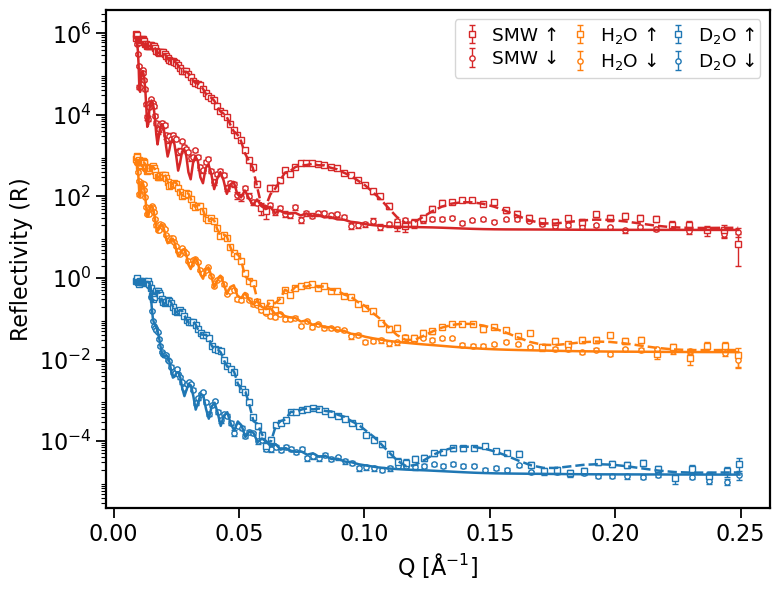

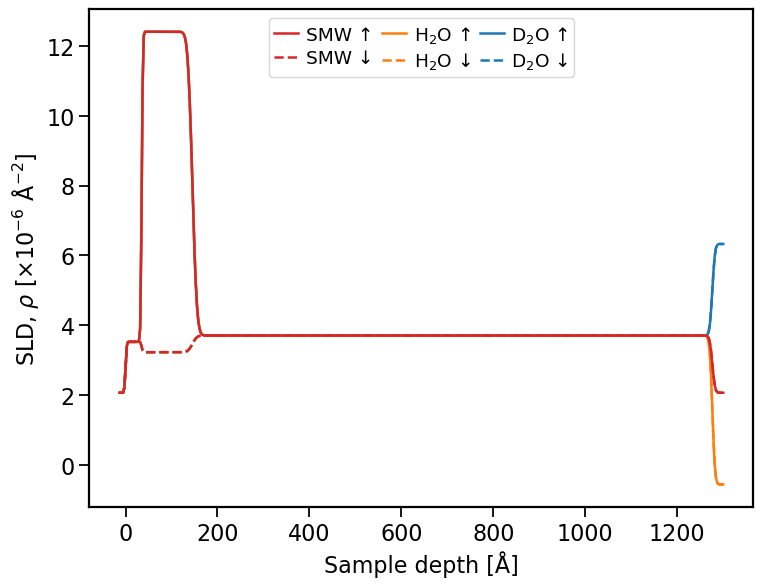

In [124]:
importlib.reload(fh)
importlib.reload(fsh)

stage1_cfg = StagePlotConfig(
    objective_group=global_objective,
    structures=[
        si_D2O_d_structure,
        si_D2O_u_structure,
        si_H2O_d_structure,
        si_H2O_u_structure,
        si_mw_d_structure,
        si_mw_u_structure,
    ],
    refl_labels=[
        r'$\mathrm{D}_{\mathrm{2}}$O ↓',
        r'$\mathrm{D}_{\mathrm{2}}$O ↑',
        r'$\mathrm{H}_{\mathrm{2}}$O ↓',
        r'$\mathrm{H}_{\mathrm{2}}$O ↑',
        'SMW ↓',
        'SMW ↑',
    ],
    sld_labels=[
        r'$\mathrm{D}_{\mathrm{2}}$O ↓',
        r'$\mathrm{D}_{\mathrm{2}}$O ↑',
        r'$\mathrm{H}_{\mathrm{2}}$O ↓',
        r'$\mathrm{H}_{\mathrm{2}}$O ↑',
        'SMW ↓',
        'SMW ↑',
    ],
    colors=["#1f77b4", "#1f77b4", "#ff7f0e", "#ff7f0e", "#d62728", "#d62728"],
    shifts=[1, 1, 1e3, 1e3, 1e6, 1e6],
    marker_styles=["o", "s", "o", "s", "o", "s"],
    model_linestyles=["-", "--", "-", "--", "-", "--"],
    data_markerfacecolors=["white"] * 6,
    data_markeredgecolors=["#1f77b4", "#1f77b4", "#ff7f0e", "#ff7f0e", "#d62728", "#d62728"],
    model_linewidth=1.8,
    data_markersize=3.8,
    data_markeredgewidth=1.0,
    axis_linewidth=1.6,
    refl_save_path=f"figures/Refl_fit_{MRL}_MRL_{Capping}_cap.svg",
    sld_save_path=f"figures/SLD_{MRL}_MRL_{Capping}_cap.svg",
    corner_save_path=f"figures/Corner_MCMC_{MRL}_MRL_{Capping}_cap.svg",
    legend_ncol=3,
    corner_left=0.15,
    corner_bottom=0.15,
)

stage1_artifacts = run_fitting_stage_plots(
    cfg=stage1_cfg,
    fitter=fitter,
    do_sampling=DO_SAMPLING,
    save_figs=SAVE_FIGS,
)

## Stage 1 summary

In [125]:
if DO_SAMPLING:
  # Fitted parameters with updated uncertainties past MCMC sampling
  print("Fitted Parameters")
  print(global_objective.varying_parameters())

### Now lets add the lipid layer, fix the substrate parameters and fit the additional data

In [126]:
data_filenames_lipid = [
                 'Sample1_Sub_lipid_p30_D2O_post_TRIS_rinse_no_bkg_subtraction_d',
                 'Sample1_Sub_lipid_p30_D2O_post_TRIS_rinse_no_bkg_subtraction_u',
                 ]

In [127]:
# Additional required parameters for adsorbed soft matter onto previous substrate assembly

# Entire stack with lipid bilayer model:
# Si | Native SiO2 | Fe MRL | SiO2 capping | inner D2O layer | lipid headgroup | tailgroup | headgroup | D2O solvent

water_thick = refnx.analysis.Parameter(6.1,    'Inner D2O layer Thick.', (3,15))

lip_heads_TRIS_thick      = refnx.analysis.Parameter(14.9,    'Lipid TRIS heads Thick.', (6,15))
lip_heads_TRIS_sld        = refnx.analysis.Parameter(1.24,     'Lipid TRIS heads SLD', (1.2,2))

lip_heads_solv_frac         = refnx.analysis.Parameter(0.65,     'Lipid TRIS heads SLD solvf', (0.3,0.7))
heads_TRIS_sld = lip_heads_solv_frac * d2o_sld
heads_TRIS_sld += (1 - lip_heads_solv_frac) * lip_heads_TRIS_sld

lip_tails_TRIS_thick        = refnx.analysis.Parameter(30.3,    'Lipid TRIS tails Thick.', (25,40))
lip_tails_TRIS_sld          = refnx.analysis.Parameter(-0.16,     'Lipid TRIS tails SLD', (-0.5,3))

lip_tails_solv_frac         = refnx.analysis.Parameter(0.11,     'Lipid TRIS tails SLD solvf', (0,0.2))
tails_TRIS_sld = lip_tails_solv_frac * d2o_sld
tails_TRIS_sld += (1 - lip_tails_solv_frac) * lip_tails_TRIS_sld

lip_TRIS_rough        = refnx.analysis.Parameter(3,     'Lipid TRIS Rough.', (3,6))

# Make the slabs
water = refnx.reflect.Slab(water_thick, d2o_sld, lip_TRIS_rough, vfsolv=0.0)
lip_heads_TRIS_layer = refnx.reflect.Slab(lip_heads_TRIS_thick, heads_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)
lip_tails_TRIS_layer = refnx.reflect.Slab(lip_tails_TRIS_thick, tails_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)

In [128]:
# Fix all substrate parameters we just fitted
for param in params:
    param.vary=False

# Define the lipid parameters and allow them to vary
params = [
        lip_heads_TRIS_thick,
        lip_heads_solv_frac,
        lip_tails_TRIS_thick,
        lip_tails_solv_frac,
        water_thick
        ]

for param in params:
    param.vary=True

In [129]:
# # Define new structures
si_lipid_TRIS_D2O_d_structure = substrate | sio2_nat_layer | MRL_d | cap_layer | water | lip_heads_TRIS_layer | lip_tails_TRIS_layer | lip_heads_TRIS_layer | d2o(0, rough=lip_TRIS_rough)
si_lipid_TRIS_D2O_u_structure = substrate | sio2_nat_layer | MRL_u | cap_layer | water | lip_heads_TRIS_layer | lip_tails_TRIS_layer | lip_heads_TRIS_layer | d2o(0, rough=lip_TRIS_rough)
structures_sample = [
                si_lipid_TRIS_D2O_d_structure,
                si_lipid_TRIS_D2O_u_structure
              ]
objectives_sample = []


for i, structure in enumerate(structures_sample):
    # Define the model.
    model = refnx.reflect.ReflectModel(structure,
                                      scale=scales[i],
                                      bkg=bkgs[i],
                                      dq=dq)
    # Load the measured data.
    filename = '{}.dat'.format(data_filenames_lipid[i])
    file_path = os.path.join(data_path, filename)
    data = refnx.dataset.ReflectDataset(file_path)

    # Combine model and data into an objective that can be fitted.
    objectives_sample.append(refnx.analysis.Objective(model, data))

In [130]:
sample_objective = GlobalObjective(list(objectives_sample))
fitter = CurveFitter(sample_objective)

In [131]:
result = fitter.fit('differential_evolution')

-783.6000499722802: : 22it [00:07,  2.94it/s]


In [132]:
print(f"Fitted Parameters \n {sample_objective.varying_parameters()}")

Fitted Parameters 
 ________________________________________________________________________________
Parameters:      None      
<Parameter:'Inner D2O layer Thick.', value=5.67379  +/- 2.6 , bounds=[3.0, 15.0]>
<Parameter:'Lipid TRIS heads Thick.', value=15 +/- 1.06 , bounds=[6.0, 15.0]>
<Parameter:'Lipid TRIS heads SLD solvf', value=0.654454 +/- 0.14 , bounds=[0.3, 0.7]>
<Parameter:'Lipid TRIS tails Thick.', value=30.9173 +/- 4.93 , bounds=[25.0, 40.0]>
<Parameter:'Lipid TRIS tails SLD solvf', value=0.132275 +/- 0.0328, bounds=[0.0, 0.2]>


### Plot and save reflectivity, SLD and optional corner plots (SUB+lipids in D2O fit)

Sample1_Sub_lipid_p30_D2O_post_TRIS_rinse_no_bkg_subtraction_d: chi2 = 1485.598686
Sample1_Sub_lipid_p30_D2O_post_TRIS_rinse_no_bkg_subtraction_u: chi2 = 292.127716


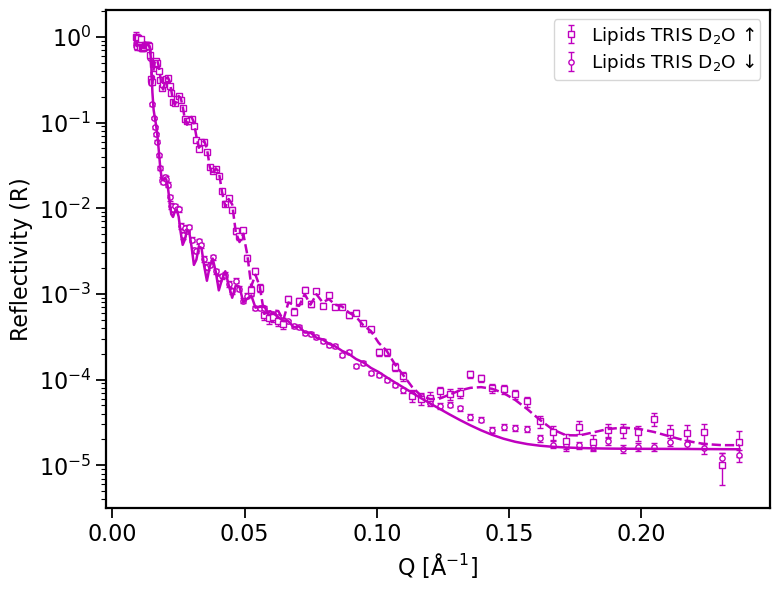

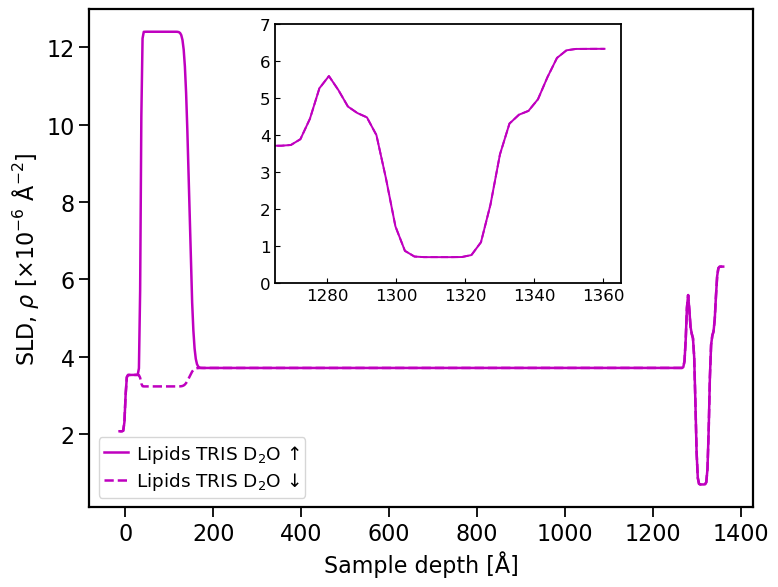

In [133]:
importlib.reload(fh)
importlib.reload(fsh)

stage2_cfg = StagePlotConfig(
    objective_group=sample_objective,
    structures=[
        si_lipid_TRIS_D2O_d_structure,
        si_lipid_TRIS_D2O_u_structure,
    ],
    refl_labels=[
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↓',
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↑',
    ],
    sld_labels=[
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↓',
        r'Lipids TRIS $\mathrm{D}_{\mathrm{2}}$O ↑',
    ],
    colors=["#bf00bf", "#bf00bf"],
    shifts=[1, 1],
    refl_save_path=f"figures/Refl_lipids_D2O_fit_{MRL}_MRL_{Capping}_cap.svg",
    sld_save_path=f"figures/SLD_lipids_D2O_{MRL}_MRL_{Capping}_cap.svg",
    corner_save_path=f"figures/Corner_MCMC_lipids_D2O_{MRL}_MRL_{Capping}_cap.svg",
    legend_ncol=None,
    corner_left=0.13,
    corner_bottom=0.13,
    marker_styles=["o", "s"],
    model_linestyles=["-", "--"],
    data_markerfacecolors=["white"] * 6,
    data_markeredgecolors=["#bf00bf", "#bf00bf"],
    model_linewidth=1.8,
    data_markersize=3.8,
    data_markeredgewidth=1.0,
    axis_linewidth=1.6,

    sld_legend_loc="lower left",

    sld_inset=True,
    sld_inset_bbox=(0.28, 0.45, 0.52, 0.52),   # top middle-ish
    sld_inset_xlim=(1265, 1365),                 # example, adjust manually
    sld_inset_ylim=(0, 7),                 # example, adjust manually
    sld_inset_show_ticks=True,
)

stage2_artifacts = run_fitting_stage_plots(
    cfg=stage2_cfg,
    fitter=fitter,
    do_sampling=DO_SAMPLING,
    save_figs=SAVE_FIGS,
)

## Stage 2 summary

In [134]:
if DO_SAMPLING:
  print("Fitted Parameters")
  print(sample_objective.varying_parameters())

In [135]:
## Save fitted parameters for subsequent FI runs
## Do not rerun after running the FI optimisation below.

fi_params = [MRL_thick, cap_thick, MRL_sld, MRL_mag]
baseline_fit = snapshot_params(fi_params)

## Fisher optimisation

In [136]:
importlib.reload(fh)
importlib.reload(fsh)

if DO_FISHER == True:
    restore_params(baseline_fit)

    # include every Parameter that affects the rebuilt structures
    model_params = [MRL_thick, cap_thick, MRL_sld, MRL_mag]

    print("Saved baseline after fitting:")
    for p in model_params:
        print(p.name, baseline_fit[p])
        # print(p.name, baseline_vals[p])

    def make_structures():
        d2o = refnx.reflect.SLD(d2o_sld)
        substrate = refnx.reflect.SLD(si_sld)
        sio2_nat_layer = refnx.reflect.Slab(sio2_native_thick, sio2_native_sld, 2, vfsolv=0.0)

        MRL_d = refnx.reflect.Slab(MRL_thick, MRL_sld - MRL_mag, 2)
        MRL_u = refnx.reflect.Slab(MRL_thick, MRL_sld + MRL_mag, 2)
        cap_layer = refnx.reflect.Slab(cap_thick, cap_sld, 2, vfsolv=0.0)

        water = refnx.reflect.Slab(water_thick, d2o_sld, lip_TRIS_rough, vfsolv=0.0)
        heads = refnx.reflect.Slab(lip_heads_TRIS_thick, heads_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)
        tails = refnx.reflect.Slab(lip_tails_TRIS_thick, tails_TRIS_sld, lip_TRIS_rough, vfsolv=0.0)

        down = substrate | sio2_nat_layer | MRL_d | cap_layer | water | heads | tails | heads | d2o(0, rough=lip_TRIS_rough)
        up   = substrate | sio2_nat_layer | MRL_u | cap_layer | water | heads | tails | heads | d2o(0, rough=lip_TRIS_rough)

        return [down, up]
    
    def make_ctx(mrl_display_name, structures, colors=None):
        if structures is None:
            raise ValueError("structures cannot be None")
        return FisherContext(
            MRL=MRL,
            Capping=Capping,
            outdir="figures",
            save_figs=SAVE_FIGS,
            baseline_vals_by_name=baseline_by_name(baseline_fit),
            mrl_display_name=mrl_display_name,
            mrl_thick_name=MRL_thick.name,
            cap_thick_name=cap_thick.name,
            mrl_sld_name=MRL_sld.name,
            mrl_mag_name=MRL_mag.name,
            structures=structures,
            colors=colors if colors is not None else ["#1f77b4", "#1f77b4"],
        )

Saved baseline after fitting:
Fe Thickness 110.2604705314392
Cap SiO2 Thickness 1131.318405187323
Fe nSLD 7.817159110088295
Fe mSLD 4.584280209438093


### FI case 1: optimise Fe MRL and SiO2 capping thicknesses only

The parameters with the highest information could be found at:
Fe Thickness: 12.2
Cap SiO2 Thickness: 5.6
-----------------------------------------------------------------
The minimum eigenvalue of the Fisher Information before optimization: 0.036
The minimum eigenvalue of the Fisher Information after optimization: 0.163
The information content is 4.54 times as large after optimization.
Open figures after optimise: [1, 2, 3, 4]
  DEBUG eigen title: 'Fe Thickness'
  DEBUG looking for: 'Fe Thickness', 'Cap SiO2 Thickness'
Saved: Fisher_case1_Fe_MRL_SiO2_cap_eigen_Fe_thick.svg
  DEBUG eigen title: 'Cap SiO2 Thickness'
  DEBUG looking for: 'Fe Thickness', 'Cap SiO2 Thickness'
Saved: Fisher_case1_Fe_MRL_SiO2_cap_eigen_SiO2_thick.svg
Saved: Fisher_case1_Fe_MRL_SiO2_cap_sld.svg
Saved: Fisher_case1_Fe_MRL_SiO2_cap_refl.svg
Available keys: ['eigen_Fe_thick', 'eigen_SiO2_thick', 'sld', 'refl']
Panel saved: Panel_Fisher_case1.svg (2×2, cell 478×359 pt + 0 pt gap)


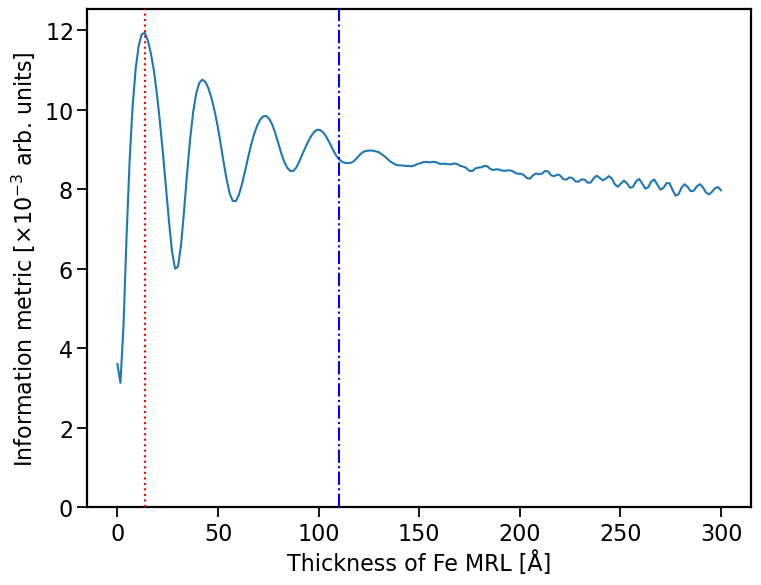

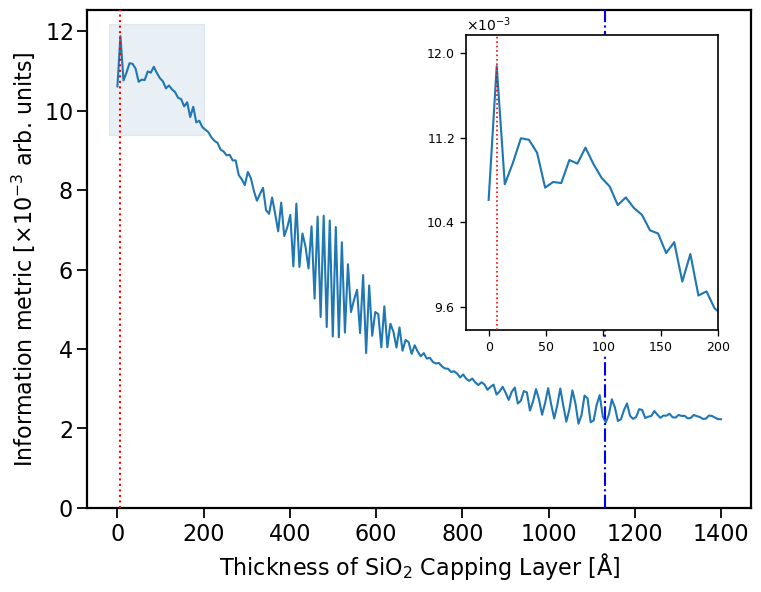

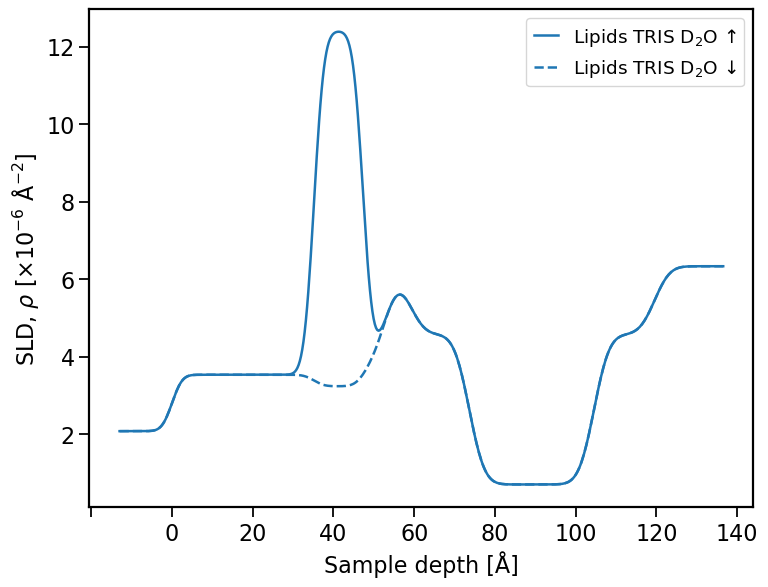

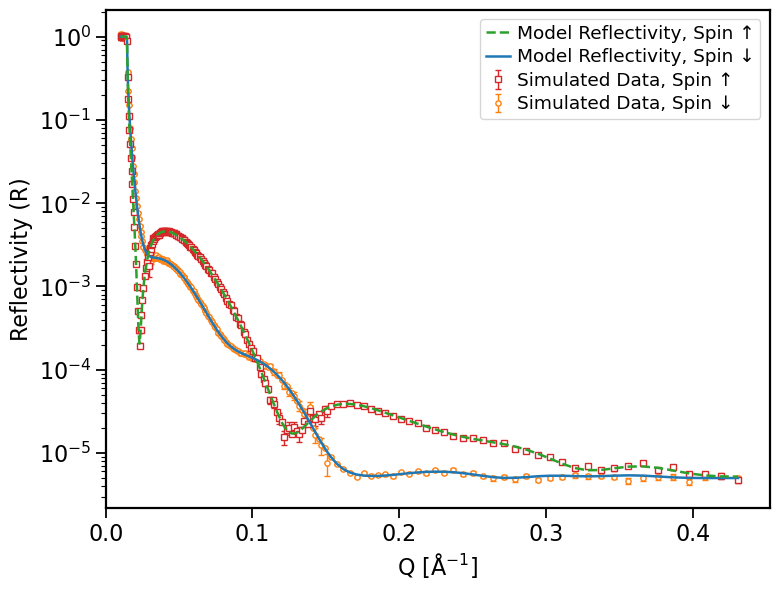

In [137]:
importlib.reload(fh)
importlib.reload(fsh)

if DO_FISHER == True:
    structures_sample = reset_to_fitted_baseline(baseline_fit, model_params, make_structures)
    ctx = make_ctx("Fe", structures_sample)
    optimisable_sample = Sample(structures_sample)

    MRL_thick.optimize = True
    MRL_thick.bounds = (0, 300)

    cap_thick.optimize = True
    cap_thick.bounds = (0, 1400)

    MRL_sld.optimize = False
    MRL_mag.optimize = False

    angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
    
    # Case 1 2×2: [eigval_MRL, eigval_cap, SLD, refl]
    import unittest.mock as mock

    plt.close("all")

    # Suppress plt.show() so hogben's figures stay open for processing
    with mock.patch("matplotlib.pyplot.show"):
        optimise_parameters(optimisable_sample, angle_times, "POLREF")

    print("Open figures after optimise:", plt.get_fignums())
    paths1 = process_hogben_figures(ctx, filename_stem="Fisher_case1")
    print("Available keys:", list(paths1.keys()))

    assemble_panel(
        svg_paths=[
            paths1[f"eigen_{MRL}_thick"],
            paths1[f"eigen_{Capping}_thick"],
            paths1["sld"],
            paths1["refl"],
        ],
        ncols=2,
        out_path="figures/Panel_Fisher_case1.svg",
        gap=0.0,
    )
    cairosvg.svg2pdf(
        url=str(Path("figures/Panel_Fisher_case1.svg").resolve()),
        write_to="figures/Panel_Fisher_case1.pdf",
    )

### FI case 2: optimise trial MRL thickness + nSLD + mSLD and SiO2 capping thickness

The parameters with the highest information could be found at:
Fe Thickness: 12.2
Cap SiO2 Thickness: 1.92
Fe mSLD: 6
Fe nSLD: 5.1
-----------------------------------------------------------------
The minimum eigenvalue of the Fisher Information before optimization: 0.036
The minimum eigenvalue of the Fisher Information after optimization: 0.201
The information content is 5.59 times as large after optimization.
  DEBUG eigen title: 'Fe Thickness'
  DEBUG looking for: 'Fe Thickness', 'Cap SiO2 Thickness'
Saved: Fisher_case2_Trial_MRL_SiO2_cap_eigen_Fe_thick.svg
  DEBUG eigen title: 'Cap SiO2 Thickness'
  DEBUG looking for: 'Fe Thickness', 'Cap SiO2 Thickness'
Saved: Fisher_case2_Trial_MRL_SiO2_cap_eigen_SiO2_thick.svg
  DEBUG eigen title: 'Fe mSLD'
  DEBUG looking for: 'Fe Thickness', 'Cap SiO2 Thickness'
Saved: Fisher_case2_Trial_MRL_SiO2_cap_eigen_Fe_msld.svg
  DEBUG eigen title: 'Fe nSLD'
  DEBUG looking for: 'Fe Thickness', 'Cap SiO2 Thickness'
Saved: Fisher_case2_Trial_MRL_SiO2_cap

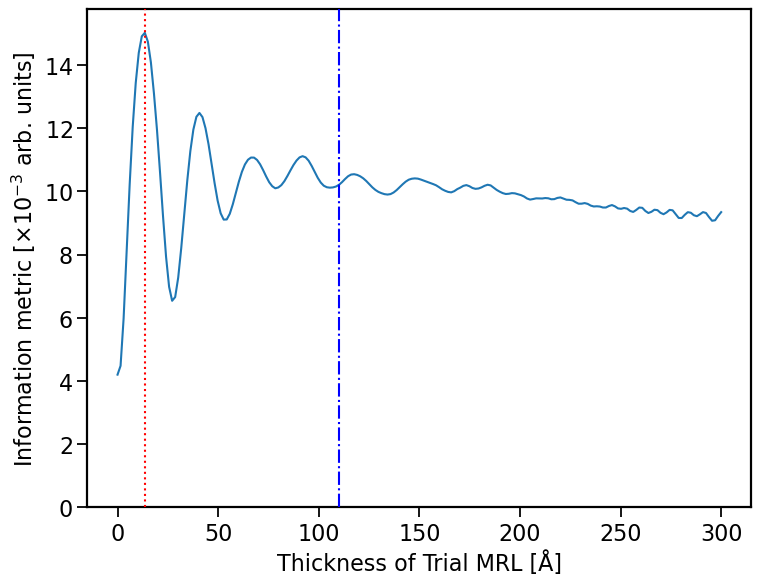

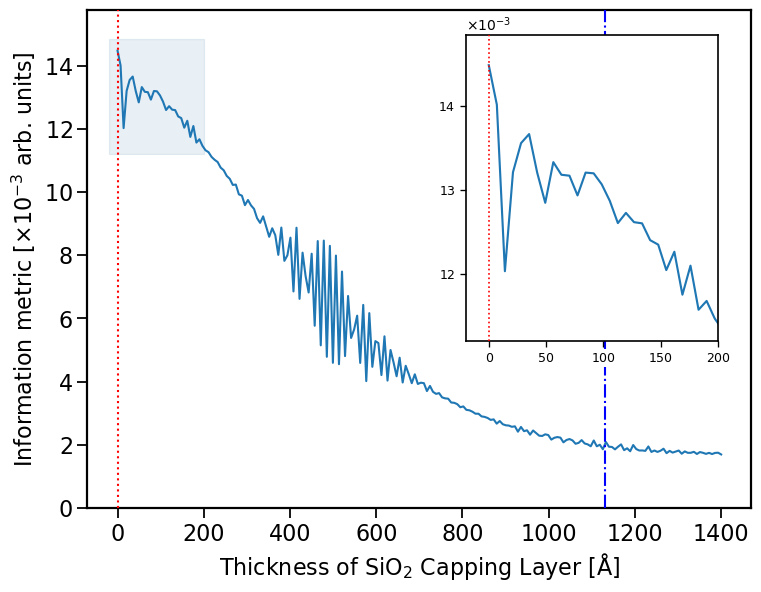

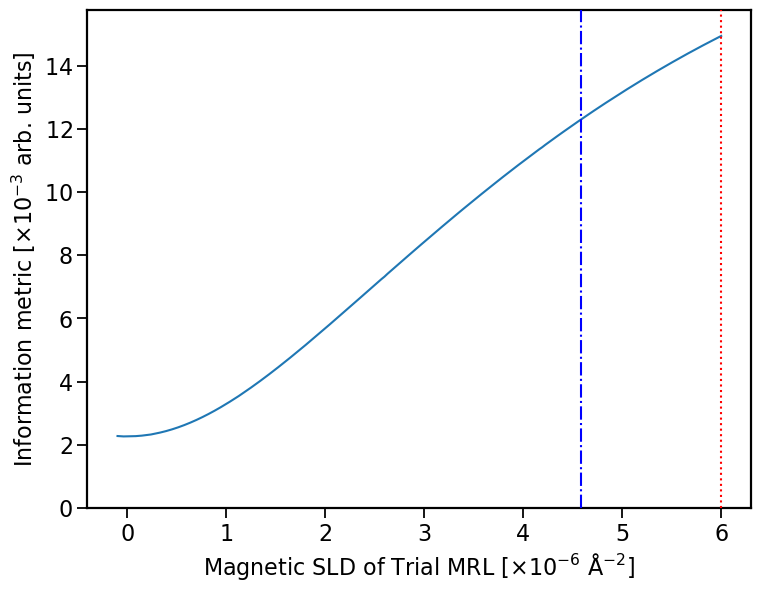

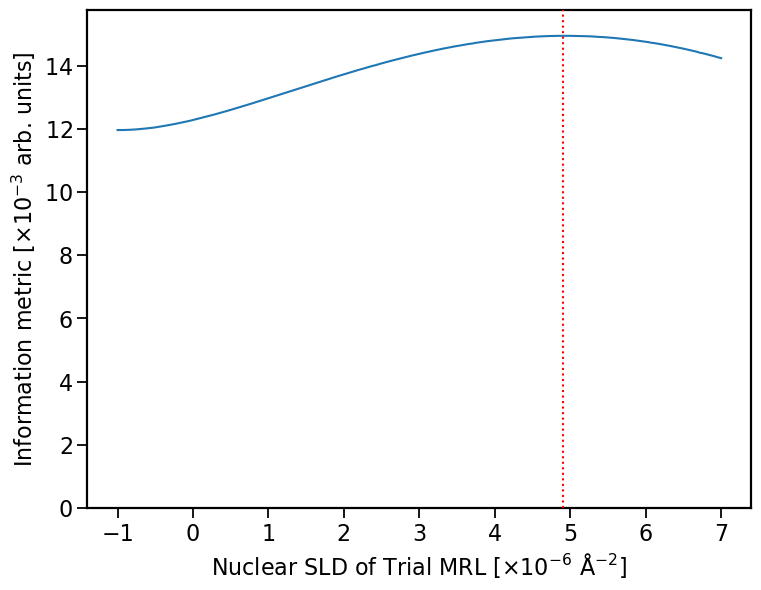

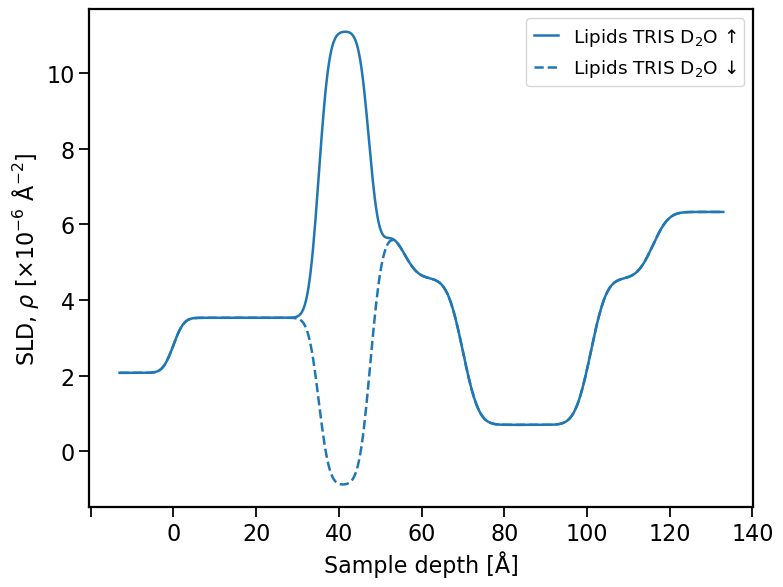

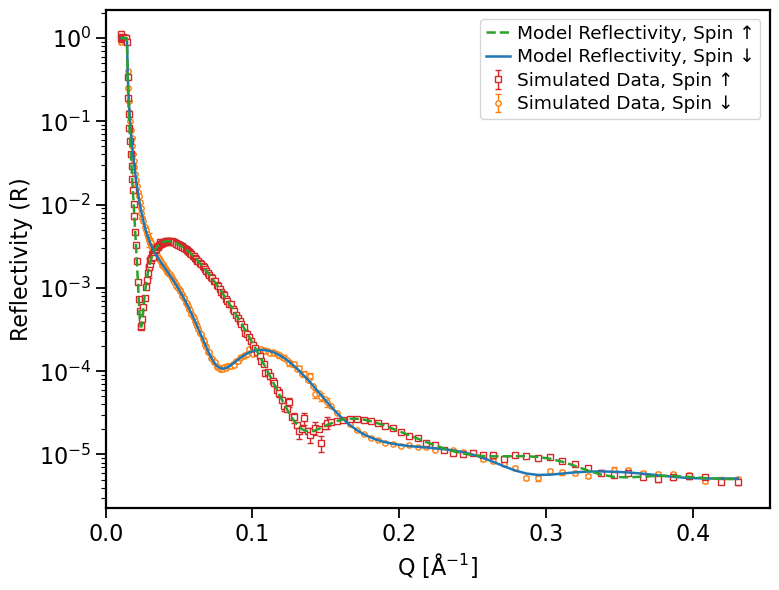

In [138]:
importlib.reload(fh)
importlib.reload(fsh)

if DO_FISHER == True:
    structures_sample = reset_to_fitted_baseline(baseline_fit, model_params, make_structures)
    ctx = make_ctx("Trial", structures_sample)
    optimisable_sample = Sample(structures_sample)

    MRL_thick.optimize = True
    MRL_thick.bounds = (0, 300)

    cap_thick.optimize = True
    cap_thick.bounds = (0, 1400)

    MRL_sld.optimize = True
    MRL_sld.bounds = (-1, 7)

    MRL_mag.optimize = True
    MRL_mag.bounds = (-0.1, 6)

    plt.close("all")
    angle_times = [(0.7, 100, 25), (2.0, 100, 75)]
    optimise_parameters(optimisable_sample, angle_times, "POLREF")

    # Case 2 3×2: [eigval×4, SLD, refl]
    paths2 = process_hogben_figures(ctx, filename_stem="Fisher_case2")

    assemble_panel(
        svg_paths=[
            paths2[f"eigen_{MRL}_thick"],
            paths2[f"eigen_{Capping}_thick"],
            paths2[f"eigen_{MRL}_nsld"],
            paths2[f"eigen_{MRL}_msld"],
            paths2["sld"],
            paths2["refl"],
        ],
        ncols=2,
        out_path="figures/Panel_Fisher_case2.svg",
        gap=0.0,
    )
    cairosvg.svg2pdf(
        url=str(Path("figures/Panel_Fisher_case2.svg").resolve()),
        write_to="figures/Panel_Fisher_case2.pdf",
)